# A* Pathfinding Visualizer

An interactive, beginner-friendly comparison of **Dijkstra's algorithm** and **A\***.

## The idea

Both algorithms search for the cheapest path through a weighted graph.
The only difference is *which node they pick next* from the frontier.

**Dijkstra** always expands the node with the smallest cost-so-far:

$$f(n) = g(n)$$

**A\*** expands the node with the smallest *estimated total* cost:

$$f(n) = g(n) + h(n)$$

where:

- $g(n)$ = **cost already travelled** from the start to node $n$
- $h(n)$ = **estimated remaining cost** from node $n$ to the goal (the *heuristic*)
- $f(n)$ = **estimated total cost** of a path through $n$

## Why the heuristic gives A* "a sense of direction"

With $h(n) = 0$, A* becomes **exactly Dijkstra** — it spreads out evenly in
all directions, blindly exploring everything cheaper than the goal.

With a good $h(n)$, nodes that lie *towards the goal* get a lower $f$-score,
so A* prefers them. The search bends toward the goal and typically expands
far fewer nodes — while still finding the shortest path, as long as $h$
never **overestimates** the true remaining cost (an *admissible* heuristic).

## The graph

We use a 4×4 grid. Start = **A1** (top-left), Goal = **P4** (bottom-right).
Every edge has a weight, and all edges go both ways.

Use the buttons at the bottom of the notebook:
**[Reset]**, **[Next Step]**, **[Run A*]**, **[Run Dijkstra]** and watch how
the two strategies explore the grid differently.

## 0. Setup

Run this first cell once — it installs the required libraries into whichever Python environment this notebook is running in. `%pip install` always targets the notebook's own kernel, so this works in Jupyter, JupyterLab and VS Code alike.

In [2]:
%pip install -q networkx matplotlib ipywidgets

import networkx as nx, matplotlib, ipywidgets
print('networkx', nx.__version__, '| matplotlib', matplotlib.__version__, '| ipywidgets', ipywidgets.__version__)


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
networkx 3.6.1 | matplotlib 3.11.0 | ipywidgets 8.1.9


## 1. Build the graph

We lay the 16 nodes out on a 4×4 grid and add horizontal and vertical edges with the weights from the diagram.

In [3]:
import heapq
import math
from itertools import count

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- the 4x4 grid from the diagram -------------------------------------
# names[i][j]: i = row (0..3), j = column (0..3)
NAMES = [
    ["A1", "B2", "C3", "D4"],
    ["E1", "F2", "G3", "H4"],
    ["I1", "J2", "K3", "L4"],
    ["M1", "N2", "O3", "P4"],
]

START, GOAL = "A1", "P4"

# horizontal edge weights (row by row)
H_WEIGHTS = [
    [1, 2, 3],      # A1-B2, B2-C3, C3-D4
    [8, 9, 10],     # E1-F2, F2-G3, G3-H4
    [15, 16, 17],   # I1-J2, J2-K3, K3-L4
    [22, 23, 24],   # M1-N2, N2-O3, O3-P4
]

# vertical edge weights (column by column, 4 columns x 3 gaps)
V_WEIGHTS = [
    [4, 11, 18],    # below A1
    [5, 12, 19],    # below B2
    [6, 13, 20],    # below C3
    [7, 14, 21],    # below D4
]

G = nx.Graph()
for row in NAMES:
    for name in row:
        G.add_node(name)

for i in range(4):                       # horizontal edges
    for j in range(3):
        G.add_edge(NAMES[i][j], NAMES[i][j + 1], weight=H_WEIGHTS[i][j])

for j in range(4):                       # vertical edges
    for i in range(3):
        G.add_edge(NAMES[i][j], NAMES[i + 1][j], weight=V_WEIGHTS[j][i])

# fixed positions: a square 4x4 grid (drawn top-left = A1)
POS = {NAMES[i][j]: (j, -i) for i in range(4) for j in range(4)}

MIN_EDGE_COST = min(d["weight"] for _, _, d in G.edges(data=True))
ALL_NODES = list(G.nodes)
print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Cheapest edge in the graph costs {MIN_EDGE_COST}")

Graph built: 16 nodes, 24 edges
Cheapest edge in the graph costs 1


## 2. Where does h(n) come from?

Two separate concepts are at work here:

```text
GRAPH                      HEURISTIC
connections + costs        estimate of remaining cost
      ↓                            ↓
    g(n)                         h(n)
```

The graph says things like `A1 → B2 = 1`, `A1 → E1 = 4`, `B2 → F2 = 5` …
Those numbers are **costs**, not distances on a map. So instead of borrowing
a geographic formula like Manhattan distance — which silently assumes
"moving one grid cell costs 1", an assumption this graph does not make —
we build heuristics **directly out of the graph itself**.

### Mode 1 — Dijkstra: h(n) = 0

`f(n) = g(n)`. Dijkstra has no knowledge of the goal beyond whether it has
reached it. It spreads evenly through the graph, cheapest-first.

### Mode 2 — graph-aware lower bound

Any path from node `n` to the goal must use **at least**
`min_edges_to_goal(n)` edges (a plain BFS that ignores weights), and every
one of those edges costs **at least** `MIN_EDGE_COST` (here, 1). Therefore

$$h(n) = \text{min\_edges\_to\_goal}(n) \times \text{MIN\_EDGE\_COST}$$

is a guaranteed **lower bound** on the true remaining cost — it can never
overestimate, so A* stays optimal. That is exactly what "admissible" means.

### Mode 3 — perfect heuristic

Because the graph is small, one reverse shortest-path sweep from the goal
gives the **exact cheapest remaining cost** from every node:

$$h(n) = \text{exact cost from } n \text{ to goal}$$

That is trivially admissible — it *is* the answer — and it turns A* into a
search that walks almost straight along the optimal path. (The sweep below
only *builds* the heuristic; the A* search itself is written by hand and
never uses it.)

| mode | formula | admissible? | strength |
|---|---|---|---|
| `zero` | $h(n)=0$ | yes (= Dijkstra) | none |
| `graph` | min edges × min edge cost | yes | cautious lower bound |
| `perfect` | exact remaining cost | yes | exact |

In [3]:
from collections import deque

def min_edges_to(goal):
    """Fewest number of edges from every node to `goal` (BFS, weights ignored)."""
    dist = {goal: 0}
    queue = deque([goal])
    while queue:
        u = queue.popleft()
        for v in G.neighbors(u):
            if v not in dist:
                dist[v] = dist[u] + 1
                queue.append(v)
    return dist

def exact_cost_to(goal):
    """Cheapest weighted cost from every node to `goal`.

    One reverse Dijkstra sweep from the goal. Used ONLY to build the
    'perfect' teaching heuristic — the A* search itself is implemented by
    hand further down and never calls this.
    """
    dist = {n: math.inf for n in G.nodes}
    dist[goal] = 0
    heap = [(0, goal)]
    while heap:
        d, u = heapq.heappop(heap)
        if d > dist[u]:
            continue
        for v in G.neighbors(u):
            nd = d + G[u][v]["weight"]
            if nd < dist[v]:
                dist[v] = nd
                heapq.heappush(heap, (nd, v))
    return dist

MIN_EDGES_TO_GOAL = min_edges_to(GOAL)
EXACT_COST_TO_GOAL = exact_cost_to(GOAL)

HEURISTICS = {   # key -> (human-readable label, h function)
    "zero":    ("Dijkstra (h = 0)",
                lambda n: 0),
    "graph":   ("A* lower bound (min edges x min edge cost)",
                lambda n: MIN_EDGES_TO_GOAL[n] * MIN_EDGE_COST),
    "perfect": ("A* perfect heuristic (exact remaining cost)",
                lambda n: EXACT_COST_TO_GOAL[n]),
}

def make_heuristic(name):
    """Return the h function for 'zero' | 'graph' | 'perfect'."""
    return HEURISTICS[name][1]

print(f"{'node':<6}{'min edges to goal':>18}{'h lower bound':>15}{'h exact':>10}")
print("-" * 50)
for n in ALL_NODES:
    print(f"{n:<6}{MIN_EDGES_TO_GOAL[n]:>18}"
          f"{MIN_EDGES_TO_GOAL[n] * MIN_EDGE_COST:>15}"
          f"{EXACT_COST_TO_GOAL[n]:>10.0f}")

node   min edges to goal  h lower bound   h exact
--------------------------------------------------
A1                     6              6        48
B2                     5              5        47
C3                     4              4        45
D4                     3              3        42
E1                     5              5        52
F2                     4              4        52
G3                     3              3        45
H4                     2              2        35
I1                     4              4        63
J2                     3              3        54
K3                     2              2        38
L4                     1              1        21
M1                     3              3        69
N2                     2              2        47
O3                     1              1        24
P4                     0              0         0


## 3. The A* algorithm (step by step)

The whole algorithm lives in one readable class. Each call to `step()`
does **one expansion** and stops, so we can watch it in slow motion.

The priority queue (a `heapq`) always gives us the open node with the
**lowest f-score** first — that single choice is the entire difference
between Dijkstra and A*.

In [4]:
class AStarStepper:
    """Step-by-step A*. With h=0 it behaves exactly like Dijkstra."""

    def __init__(self, graph, start, goal, heuristic="graph"):
        self.graph = graph
        self.start, self.goal = start, goal
        self.set_heuristic(heuristic)

    def set_heuristic(self, name):
        """Choose 'zero' | 'graph' | 'perfect' and start a fresh search."""
        self.heuristic_name = name
        self.h = make_heuristic(name)
        self.reset()

    def reset(self):
        """Back to the very beginning: only the start node is known."""
        self.g = {n: math.inf for n in self.graph.nodes}   # cost travelled
        self.g[self.start] = 0
        self.h_score = {n: self.h(n) for n in self.graph.nodes}
        self.f = {n: self.g[n] + self.h_score[n] for n in self.graph.nodes}
        self.came_from = {}                                 # for rebuilding path
        self.closed = set()                                 # finished nodes
        self.current = None
        self._tie = count()                                 # FIFO tie-breaking
        self.open_heap = [(self.f[self.start], next(self._tie), self.start)]
        self.open_set = {self.start}
        self.done = False
        self.path = None
        self.expanded_count = 0

    def step(self):
        """Expand one node. Returns False when the search is finished."""
        if self.done:
            return False

        # --- pick the OPEN node with the lowest f(n)  (THE key line) ---
        _, _, node = heapq.heappop(self.open_heap)
        self.open_set.discard(node)
        self.current = node

        if node == self.goal:                # reached the goal -> rebuild path
            self.done = True
            self.path = self._reconstruct()
            return False

        self.closed.add(node)                # node is now finished
        self.expanded_count += 1

        # --- relax neighbours: is going through `node` cheaper? ---
        for nb in self.graph.neighbors(node):
            if nb in self.closed:
                continue
            tentative_g = self.g[node] + self.graph[node][nb]["weight"]
            if tentative_g < self.g[nb]:
                self.g[nb] = tentative_g
                self.f[nb] = tentative_g + self.h_score[nb]
                self.came_from[nb] = node
                heapq.heappush(self.open_heap, (self.f[nb], next(self._tie), nb))
                self.open_set.add(nb)
        return True

    def run(self):
        """Keep stepping until the goal is reached (or nothing left)."""
        while self.step():
            pass
        return self.path

    def _reconstruct(self):
        """Walk came_from backwards from goal to start."""
        path, node = [self.goal], self.goal
        while node != self.start:
            node = self.came_from[node]
            path.append(node)
        return path[::-1]

print("AStarStepper defined. Try: s = AStarStepper(G, START, GOAL); s.step()")

AStarStepper defined. Try: s = AStarStepper(G, START, GOAL); s.step()


## 4. Drawing the graph

Each node is drawn as a dark square whose colour shows its state, and every
edge shows its weight. The colour legend:

| Colour | State | Meaning |
|---|---|---|
| green | START / GOAL | the endpoints |
| orange | OPEN | discovered, waiting in the priority queue |
| grey | CLOSED | already expanded |
| red | CURRENT | the node being expanded right now |
| blue | FINAL PATH | the shortest path found

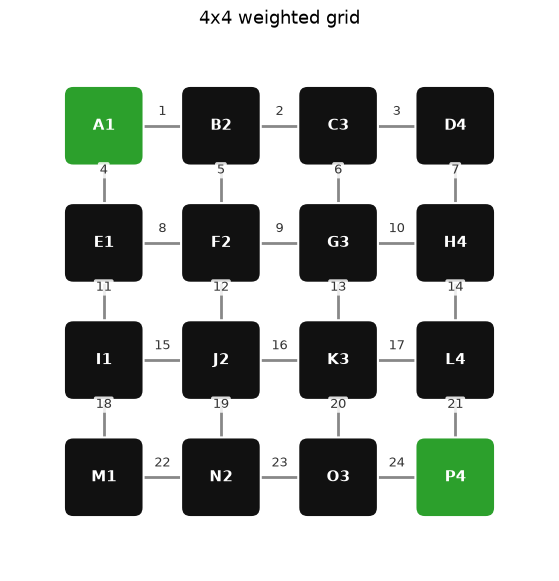

In [5]:
COLORS = {
    "start":   "#2ca02c",
    "goal":    "#2ca02c",
    "open":    "#ff9d2e",
    "closed":  "#555555",
    "current": "#e63946",
    "path":    "#1f77b4",
    "plain":   "#111111",
}

def draw_graph(stepper=None, ax=None):
    """Draw the grid; if a stepper is given, colour it by search state."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))
    else:
        fig = ax.figure

    state = {n: "plain" for n in ALL_NODES}
    if stepper is not None:
        for n in stepper.open_set:
            state[n] = "open"
        for n in stepper.closed:
            state[n] = "closed"
        if stepper.current and not stepper.done:
            state[stepper.current] = "current"
        if stepper.path:                       # finished: highlight the path
            for n in stepper.path:
                state[n] = "path"
    state[START], state[GOAL] = "start", "goal"

    # edges (+ bold blue for the final path)
    path_edges = set()
    if stepper is not None and stepper.path:
        path_edges = {frozenset((a, b)) for a, b in zip(stepper.path, stepper.path[1:])}

    for u, v, d in G.edges(data=True):
        is_path = frozenset((u, v)) in path_edges
        nx.draw_networkx_edges(
            G, POS, edgelist=[(u, v)], ax=ax,
            width=5 if is_path else 2,
            edge_color=COLORS["path"] if is_path else "#888888",
        )
        mx, my = (POS[u][0] + POS[v][0]) / 2, (POS[u][1] + POS[v][1]) / 2
        ax.text(mx, my + 0.12, str(d["weight"]), fontsize=9,
                ha="center", va="center", color="#333333",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))

    # nodes as dark squares with white labels
    for n in ALL_NODES:
        x, y = POS[n]
        ax.add_patch(FancyBboxPatch(
            (x - 0.32, y - 0.32), 0.64, 0.64,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            fc=COLORS[state[n]], ec="white", lw=1.5, zorder=2))
        ax.text(x, y, n, color="white", fontsize=11, fontweight="bold",
                ha="center", va="center", zorder=3)

    ax.set_xlim(-0.8, 3.8)
    ax.set_ylim(-3.8, 0.8)
    ax.set_aspect("equal")
    ax.axis("off")
    title = "4x4 weighted grid"
    if stepper is not None:
        title += f"  —  {HEURISTICS[stepper.heuristic_name][0]}"
        if stepper.path:
            title += f"  —  path cost {stepper.g[GOAL]}"
    ax.set_title(title, fontsize=13)
    return fig

fig = draw_graph()
plt.show()

## 5. The score table

After each step we print a table of every discovered node:
`g(n)` = cost so far, `h(n)` = estimate to go, `f(n)` = g + h.
It is sorted by f-score (the priority the queue uses), then by g.

In [6]:
def print_table(stepper, max_rows=16):
    """NODE | g | h | f | STATE, sorted by f (queue priority)."""
    rows = []
    for n in ALL_NODES:
        if stepper.g[n] is math.inf and n not in stepper.open_set:
            continue
        if n == START:
            st = "START"
        elif n == GOAL and stepper.done:
            st = "GOAL"
        elif n in (stepper.path or []):
            st = "PATH"
        elif n == stepper.current and not stepper.done:
            st = "CURRENT"
        elif n in stepper.closed:
            st = "CLOSED"
        elif n in stepper.open_set:
            st = "OPEN"
        else:
            st = "-"
        rows.append((stepper.f[n], stepper.g[n], n, stepper.h_score[n], st))
    rows.sort()
    print(f"{'NODE':<6}{'g(n)':>8}{'h(n)':>8}{'f(n)':>8}   STATE")
    print("-" * 42)
    for f_, g_, n, h_, st in rows[:max_rows]:
        gs = "inf" if g_ is math.inf else f"{g_:.0f}"
        fs = "inf" if f_ is math.inf else f"{f_:.0f}"
        print(f"{n:<6}{gs:>8}{h_:>8.0f}{fs:>8}   {st}")
    print("-" * 42)
    print(f"expanded so far: {stepper.expanded_count}   open: {len(stepper.open_set)}   closed: {len(stepper.closed)}")

# quick smoke test of one step
demo = AStarStepper(G, START, GOAL)
demo.step()
print_table(demo)

NODE      g(n)    h(n)    f(n)   STATE
------------------------------------------
A1           0       6       6   START
B2           1       5       6   OPEN
E1           4       5       9   OPEN
------------------------------------------
expanded so far: 1   open: 2   closed: 1


## 6. Interactive step-by-step mode

Now the main event. Pick a heuristic from the dropdown — the same search
code runs in all three modes; only h(n) changes:

- **Dijkstra — h = 0** : no sense of direction
- **A* — graph-aware lower bound** : a cautious, admissible estimate
- **A* — perfect heuristic** : the exact remaining cost

Buttons: **[Reset]** start over, **[Next Step]** expand exactly one node,
**[Run to end]** finish the search. Watch how the orange "open" ring
behaves in each mode.

In [7]:
stepper = AStarStepper(G, START, GOAL, heuristic="graph")

out = widgets.Output()

mode_dropdown = widgets.Dropdown(
    value="graph",
    options=[
        ("Dijkstra — h = 0", "zero"),
        ("A* — graph-aware lower bound", "graph"),
        ("A* — perfect heuristic", "perfect"),
    ],
    description="Heuristic:",
    layout=widgets.Layout(width="340px"),
)

def render():
    with out:
        clear_output(wait=True)
        draw_graph(stepper)
        plt.show()
        print_table(stepper)

def on_reset(_):
    stepper.reset()
    render()

def on_step(_):
    if stepper.done:
        with out:
            print("Search finished — press Reset to start again.")
        return
    stepper.step()
    render()

def on_run(_):
    stepper.run()
    render()

def on_mode(change):
    stepper.set_heuristic(change["new"])   # swaps h and resets
    render()

btn_reset = widgets.Button(description="Reset", button_style="")
btn_step  = widgets.Button(description="Next Step", button_style="info")
btn_run   = widgets.Button(description="Run to end", button_style="success")

btn_reset.on_click(on_reset)
btn_step.on_click(on_step)
btn_run.on_click(on_run)
mode_dropdown.observe(on_mode, names="value")

display(widgets.VBox([
    widgets.HBox([mode_dropdown]),
    widgets.HBox([btn_reset, btn_step, btn_run]),
]), out)
render()

Output()

## 7. Comparison: zero → lower bound → perfect

The same search runs from **A1** to **P4** three times, changing only h(n).
All three heuristics are admissible, so **all three find the shortest
path** — what changes is how much of the graph they waste time exploring:

- **Dijkstra** floods almost the whole grid: it only knows the cost paid.
- **Lower bound** is correct but cautious — real edges here cost up to 24,
  yet it only assumes `MIN_EDGE_COST = 1` per remaining step, so it barely
  beats Dijkstra on this particular graph.
- **Perfect heuristic** knows exactly what is left, so the search walks
  (nearly) straight down the optimal corridor.

The lesson: the important question is not "Manhattan or something else?"
It is **where h(n) comes from, and how tight a lower bound it is**.

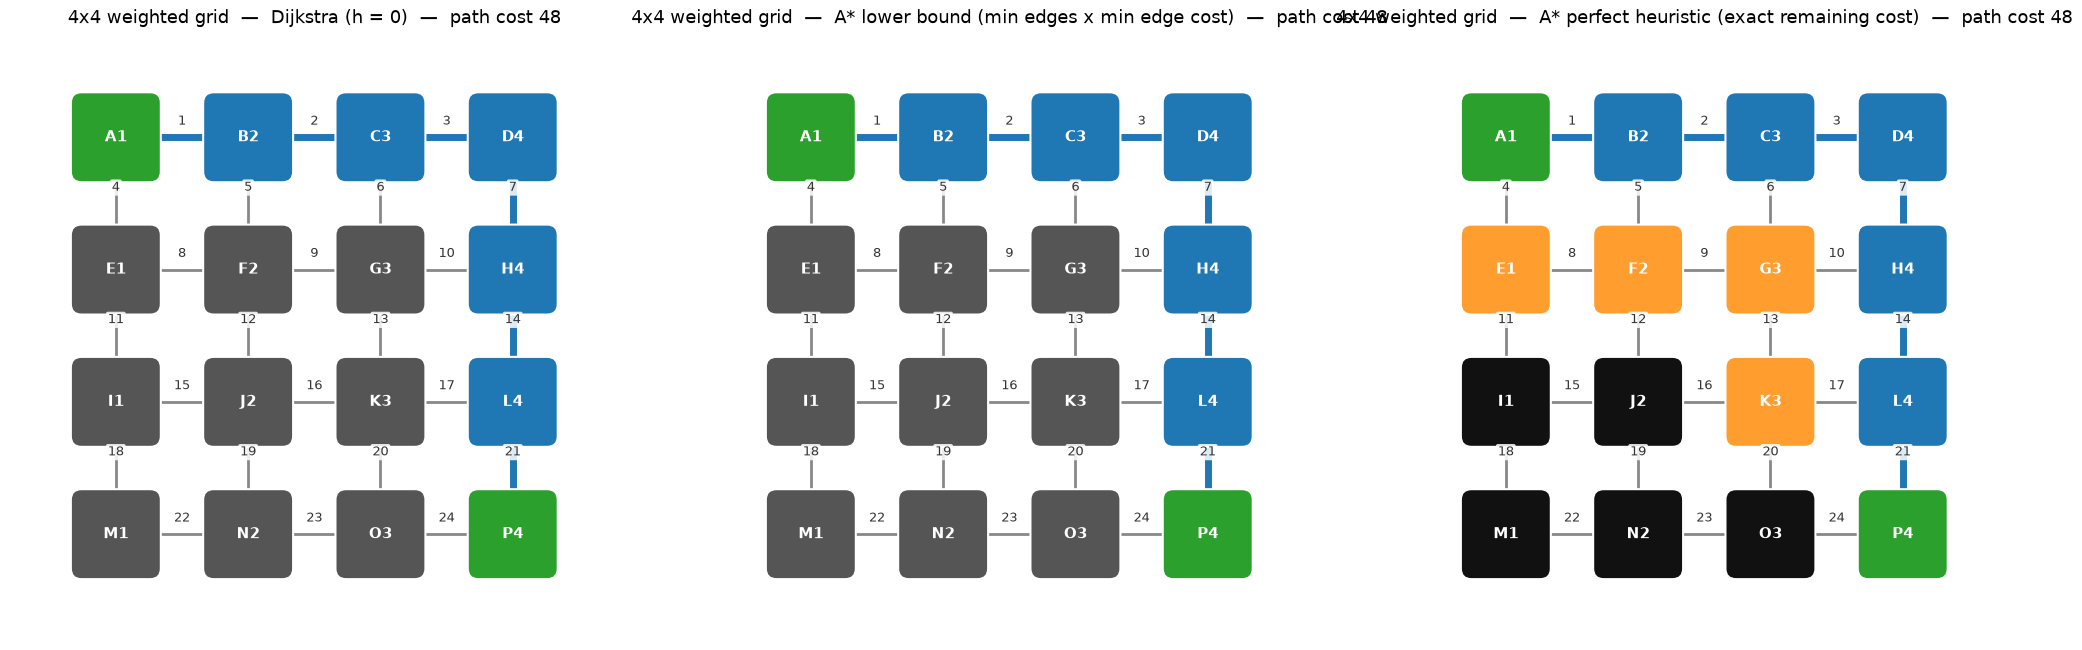

mode      heuristic                                   cost  expanded
----------------------------------------------------------------------
zero      Dijkstra (h = 0)                              48        15
graph     A* lower bound (min edges x min edge cost)    48        15
perfect   A* perfect heuristic (exact remaining cost)    48         6
----------------------------------------------------------------------
Shortest path (identical in all three modes):
  A1 -> B2 -> C3 -> D4 -> H4 -> L4 -> P4   (cost 48)


In [8]:
runs = {}
for key in ("zero", "graph", "perfect"):
    s = AStarStepper(G, START, GOAL, heuristic=key)
    path = s.run()
    runs[key] = (s, path)

fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
for ax, key in zip(axes, ("zero", "graph", "perfect")):
    draw_graph(runs[key][0], ax=ax)
plt.tight_layout()
plt.show()

print(f"{'mode':<10}{'heuristic':<42}{'cost':>6}{'expanded':>10}")
print("-" * 70)
for key in ("zero", "graph", "perfect"):
    s, p = runs[key]
    print(f"{key:<10}{HEURISTICS[key][0]:<42}{s.g[GOAL]:>6.0f}{s.expanded_count:>10}")
print("-" * 70)

paths = [p for _, p in runs.values()]
costs = [s.g[GOAL] for s, _ in runs.values()]
assert len(set(costs)) == 1, "all modes must find the same shortest-path cost"
print("Shortest path (identical in all three modes):")
print("  " + " -> ".join(paths[0]) + f"   (cost {costs[0]})")

## 8. Takeaways

```text
Dijkstra        "I only know the cost I've already paid."

A*              "I know the cost I've already paid
                  AND a lower-bound estimate of what's left."

Perfect h       "I know exactly what's left."
```

- The graph defines **g(n)**: connections and edge costs.
- The heuristic defines **h(n)**: an estimate of the remaining cost. It is
  *extra knowledge* you bring to the problem, not something the graph
  gives you.
- If h never overestimates (is **admissible**), A* is guaranteed to find a
  shortest path — the same one Dijkstra finds.
- If `h(n) = 0`, A* **is** Dijkstra.
- The **tighter** the lower bound, the fewer nodes A* expands. A weak-but-
  correct bound (like min-edges × min-edge-cost on this graph) saves little;
  a strong one can save almost everything.

Go back to the interactive section, switch the dropdown between the three
modes, and step through each one — the behaviour above is exactly what you
will see.